
## Chapter 10: Using a regression neural network to predict housing prices in Hyderabad

### Importing the necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Setting random seeds to get reproducible results
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(1)

### Importing and reading the dataset

In [2]:
# IMPORTANT: ONLY RUN THIS CELL IF YOU ARE WORKING ON A COLAB

url = "https://raw.githubusercontent.com/luisguiserrano/manning/master/Chapter_10_Neural_Networks/Hyderabad.csv"
housing = pd.read_csv(url)
housing

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,6968000,1340,Nizampet,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
1,29000000,3498,Hitech City,4,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,6590000,1318,Manikonda,2,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5739000,1295,Alwal,3,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,5679000,1145,Kukatpally,2,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2513,11000000,1460,Nacharam,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2514,26000000,1314,Manikonda,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2515,13300000,2625,Madhapur,3,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2516,10800000,2050,Hitech City,3,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [8]:
num_features = housing.shape[1]
print(f"Number of features using .shape: {num_features}")

Number of features using .shape: 40


In [26]:
print(housing.dtypes)

Price                   int64
Area                    int64
Location               object
No. of Bedrooms         int64
Resale                  int64
MaintenanceStaff        int64
Gymnasium               int64
SwimmingPool            int64
LandscapedGardens       int64
JoggingTrack            int64
RainWaterHarvesting     int64
IndoorGames             int64
ShoppingMall            int64
Intercom                int64
SportsFacility          int64
ATM                     int64
ClubHouse               int64
School                  int64
24X7Security            int64
PowerBackup             int64
CarParking              int64
StaffQuarter            int64
Cafeteria               int64
MultipurposeRoom        int64
Hospital                int64
WashingMachine          int64
Gasconnection           int64
AC                      int64
Wifi                    int64
Children'splayarea      int64
LiftAvailable           int64
BED                     int64
VaastuCompliant         int64
Microwave 

### Pre-processing the data



In [16]:
features = housing.drop(['Location', 'Price'], axis=1)
features

,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,IndoorGames,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,1340,2,0,0,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
1,3498,4,0,0,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,1318,2,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1295,3,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,1145,2,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2513,1460,2,1,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2514,1314,2,1,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2515,2625,3,1,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2516,2050,3,0,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [30]:
print("number of features:", features.shape[1])

number of features: 38


In [31]:
print("Training data (rows):", features.shape[0])

Training data (rows): 2518


In [32]:
labels = housing['Price']
labels

,Price
0,6968000
1,29000000
2,6590000
3,5739000
4,5679000
...,...
2513,11000000
2514,26000000
2515,13300000
2516,10800000


In [40]:
print(labels.min(), labels.max(), labels.mean())

2000000 165000000 9818379.636616362


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Building and training the neural network

In [43]:
# Imports
#import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
#from tensorflow.keras.layers import Dense, Dropout, Activation
#from tensorflow.keras.optimizers import SGD

# Building the model
model = Sequential()
model.add(Dense(38, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(.2))
model.add(Dense(1))

# Compiling the model (SGD, RMSProp, AdaGrad)
model.compile(loss = 'mean_squared_error', optimizer='adam', metrics=[keras.metrics.RootMeanSquaredError()])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,795 (57.79 KB)

 Trainable params: 14,795 (57.79 KB)

 Non-trainable params: 0 (0.00 B)

### Training the neural network

In [48]:
# Training the model
model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32877244841984.0000 - root_mean_squared_error: 5711193.5000 - val_loss: 31097771524096.0000 - val_root_mean_squared_error: 5576537.5000
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30884224827392.0000 - root_mean_squared_error: 5529296.0000 - val_loss: 29533791059968.0000 - val_root_mean_squared_error: 5434500.0000
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30192019963904.0000 - root_mean_squared_error: 5463352.0000 - val_loss: 28019729104896.0000 - val_root_mean_squared_error: 5293366.5000
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29650579357696.0000 - root_mean_squared_error: 5414974.0000 - val_loss: 26675481935872.0000 - val_root_mean_squared_error: 5164831.0000
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27650022178816.0000 - root_mean_squared_error: 5229184.5000 - val_loss: 25551272148992.0000 - val_root_mean_squared_error: 5054826.5000
Epoch 6/50
51/51 ━━━━━━━━━━━━━

### Evaluating the model


In [53]:
model.evaluate(features, labels)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72401037489980047360.0000 - root_mean_squared_error: 8505156096.0000


[7.890099838967087e+19, 8882623488.0]

In [54]:
y_pred = model.predict(X_test_scaled).flatten()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)
print("Relative RMSE (% of mean price):", rmse / y_test.mean() * 100, "%")

RMSE: 4490712.509688413
MAE: 2752301.25
R^2: 0.6801406145095825
Relative RMSE (% of mean price): 46.21563280158183 %


### Plotting NN model

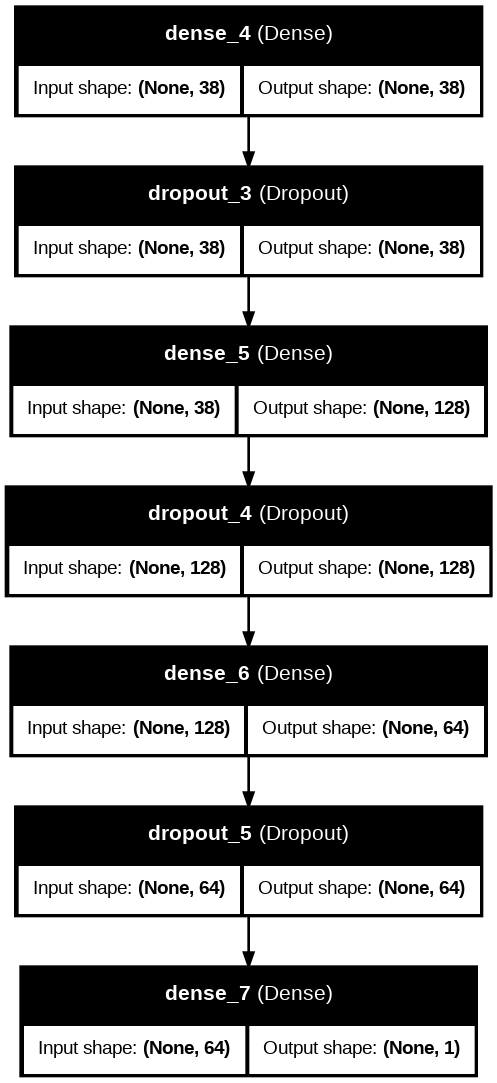

In [56]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="regression_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

### Make predictions

Average Hyderabad Apartment

In [59]:
avg_home = {
    "Area": 1500,
    "No. of Bedrooms": 3,
    "Resale": 1,
    "MaintenanceStaff": 1,
    "Gymnasium": 1,
    "SwimmingPool": 0,
    "LandscapedGardens": 1,
    "JoggingTrack": 1,
    "RainWaterHarvesting": 1,
    "IndoorGames": 1,
    "ShoppingMall": 1,
    "Intercom": 1,
    "SportsFacility": 0,
    "ATM": 1,
    "ClubHouse": 1,
    "School": 1,
    "24X7Security": 1,
    "PowerBackup": 1,
    "CarParking": 1,
    "StaffQuarter": 0,
    "Cafeteria": 0,
    "MultipurposeRoom": 1,
    "Hospital": 1,
    "WashingMachine": 1,
    "Gasconnection": 1,
    "AC": 0,
    "Wifi": 1,
    "Children'splayarea": 1,
    "LiftAvailable": 1,
    "BED": 1,
    "VaastuCompliant": 1,
    "Microwave": 1,
    "GolfCourse": 0,
    "TV": 1,
    "DiningTable": 1,
    "Sofa": 1,
    "Wardrobe": 1,
    "Refrigerator": 1
}


In [60]:
import pandas as pd

# Create dataframe for prediction
df_example = pd.DataFrame([avg_home])   # or luxury_gachibowli, etc.

# IMPORTANT: Must scale like training set
df_scaled = scaler.transform(df_example)

# Predict
pred = model.predict(df_scaled)[0][0]

print("Predicted Price:", int(pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted Price: 3289719


Luxury Gachibowli High-rise Apartment

In [62]:
luxury_gachibowli = {
    "Area": 2400,
    "No. of Bedrooms": 3,
    "Resale": 0,
    "MaintenanceStaff": 1,
    "Gymnasium": 1,
    "SwimmingPool": 1,
    "LandscapedGardens": 1,
    "JoggingTrack": 1,
    "RainWaterHarvesting": 1,
    "IndoorGames": 1,
    "ShoppingMall": 1,
    "Intercom": 1,
    "SportsFacility": 1,
    "ATM": 1,
    "ClubHouse": 1,
    "School": 1,
    "24X7Security": 1,
    "PowerBackup": 1,
    "CarParking": 2,
    "StaffQuarter": 1,
    "Cafeteria": 1,
    "MultipurposeRoom": 1,
    "Hospital": 1,
    "WashingMachine": 1,
    "Gasconnection": 1,
    "AC": 1,
    "Wifi": 1,
    "Children'splayarea": 1,
    "LiftAvailable": 1,
    "BED": 3,
    "VaastuCompliant": 1,
    "Microwave": 1,
    "GolfCourse": 0,
    "TV": 2,
    "DiningTable": 1,
    "Sofa": 1,
    "Wardrobe": 3,
    "Refrigerator": 1
}


In [63]:
# Create dataframe for prediction
df_example = pd.DataFrame([luxury_gachibowli])   # or luxury_gachibowli, etc.

# IMPORTANT: Must scale like training set
df_scaled = scaler.transform(df_example)

# Predict
pred = model.predict(df_scaled)[0][0]

print("Predicted Price:", int(pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Price: 3710458
